# Incident priority composition

**Recipe 24** · Level 3 (Intermediate) · Decision type: `Score`

Score reported business impact and urgency against separate rubrics so Python can map the scores to defined categories and apply a fixed service-priority matrix.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

An incident-priority rule for a fabricated on-call process. Jev reads one incident report and answers two independent `Score` questions about it in a single request: how much *business impact* it has, and how *urgent* a response is, each against its own four-level rubric. Jev never decides a priority; Python does. Python maps each answer's most likely level to a named category, looks up the pair of categories in a fixed priority matrix held as data, and reports that matrix lookup as the ticket's priority only when both answers are confident enough to trust; otherwise the ticket goes to an explicit `review` outcome. By the end you will have looked at a ticket where impact and urgency pull in different directions, seen the matrix and the rule that composes it, and run an evaluation that reports agreement with the gold categories per question and with the gold priority at the task level, including the risk a frozen confidence gate does and does not catch.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored tickets in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same two question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    evaluate_outcomes,
    score_level,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every ticket needs at most one request, which answers both questions together. This cache
# makes sure a ticket shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    """Both Score answers for one ticket, from one cached request."""
    if example.id not in answered:
        result = backend.decide(helpers.build_state(example.fields), questions)
        answered[example.id] = (result["business_impact"], result["urgency"])
    return answered[example.id]


def gold_priority(example_id):
    """The priority PRIORITY_MATRIX assigns to a ticket's gold categories -- the same fixed
    matrix the rule applies to Jev's answers, applied here to the human labels instead, so the
    gold priority can never drift from the matrix that judges it."""
    label = labels[example_id]
    return helpers.PRIORITY_MATRIX[(label["impact"], label["urgency"])]


run_header(
    24,
    "Incident priority composition",
    backend=backend,
    n_examples=len(scored),
)

Recipe 24: Incident priority composition
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each ticket in `fixtures/inputs.jsonl` carries `fields`: a `ticket_id` and the incident `report` text. `build_state` passes on the report text only; the identifier stays in Python and is attached to every outcome, so it never passes through the model and every result still traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-divergent"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket_id": "INC-9001",
  "report": "media-transcoder failed to generate the one highlight clip an account manager needs for a sponsor call starting in three minutes; no other customer or workflow is affected. There is no time left to find a workaround."
}
Jev sees:
{
  "report": "media-transcoder failed to generate the one highlight clip an account manager needs for a sponsor call starting in three minutes; no other customer or workflow is affected. There is no time left to find a workaround."
}


## The questions

Two questions go in one request, because they are independent: *how much business impact* and *how urgent* are both judged from the same report text, and neither answer depends on the other (S02, https://docs.typesafe.ai/primitives). Python builds each rubric's four levels from `IMPACT_LEVELS` and `URGENCY_LEVELS` in `helpers.py`, lowest to highest. TypeSafe's primitives documentation for `Score` says the model judges each level on its own against the state: "Every level is evaluated separately. The model doesn't see a level's number or its neighbours, so 'worse than the previous level' means nothing to it." Each level below is written to stand alone, naming a scope of effect or a degree of time pressure, never a comparison with its neighbours.

A `Score` answer's [`confidence`](../../docs/glossary.md#confidence) is not its top probability; the published formula (S03, https://docs.typesafe.ai/confidence) is `1 - spread / even_spread`, where `spread` is the probability-weighted distance, in levels, between the answer and its most likely level, and `even_spread` is the same kind of distance for a uniform spread over all levels. Probability placed on a level next to the peak lowers confidence less than the same probability placed further away. Python never recomputes this by hand; `jev_cookbook` already enforces it on every stored answer. Arithmetic -- mapping a level to a category, looking up the priority matrix, comparing a confidence to a threshold -- stays in Python; TypeSafe's "how to build" guidance (S04, https://docs.typesafe.ai/concepts/how-to-build-with-system-one) is to keep deterministic logic and side effects in code around a narrow semantic judgment, which is exactly the shape this recipe follows.

In [3]:
questions = helpers.build_questions()
for name, question in questions.items():
    print(name)
    print(" ", question.instructions)
    for level, description in enumerate(question.criteria):
        print(f"   {level}  {description}")

business_impact
  How much business impact does this incident have on customers and operations?
   0  The effect is contained to a small number of customers or to one non-critical feature; core operations, revenue and data are unaffected.
   1  A noticeable but partial segment of customers, or one feature many customers rely on, is degraded; there is some effect on revenue or operations, but most customers are unaffected.
   2  A core feature is broken or unavailable, or a large share of customers cannot complete what they came to do, with a clear effect on revenue, operations or customer trust.
   3  The whole customer base or a core system is affected outright, with severe effect on revenue, data integrity, safety, or legal or regulatory exposure.
urgency
  How urgently does this incident need a response?
   0  There is no deadline pressure: the incident can be scheduled into normal work with no special handling.
   1  A response is expected within the current work week; nothing desc

## One answer up close

Before any aggregate, look at two tickets that are shown but never scored. The first is a demo ticket where the two questions pull in different directions: its business impact is small but its urgency is as high as the rubric goes. The second is a demo ticket where the two questions agree instead, both critical, for contrast. Each answer holds the expected `score`, a probability for every level, the `confidence` explained above, and a [`provenance`](../../docs/glossary.md#provenance) line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

media-transcoder failed to generate the one highlight clip an account manager needs for a sponsor call starting in three minutes; no other customer or workflow is affected. There is no time left to find a workaround.

business_impact:
Score: 0.20 (confidence 0.80)
  0 The effect is contained to a small number of customers or to one non-critical feature; core operations, revenue and data are unaffected.  0.88  ##################
  1 A noticeable but partial segment of customers, or one feature many customers rely on, is degraded; there is some effect on revenue or operations, but most customers are unaffected.  0.06  #
  2 A core feature is broken or unavailable, or a large share of customers cannot complete what they came to do, with a clear effect on revenue, operations or customer trust.  0.04  #
  3 The whole customer base or a core system is affected outright, with severe effect on revenue, data integrity, safety, or legal or regulatory exposure.  0.02  
Provenance: synthetic

urge

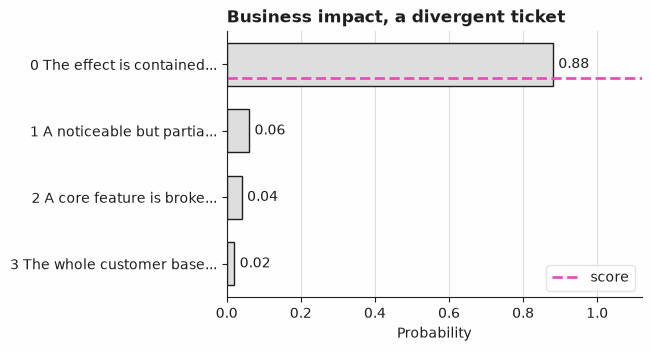

In [4]:
divergent_example = demo["d01-divergent"]
impact_answer, urgency_answer = decide(divergent_example)
print(divergent_example.fields["report"])
print()
print("business_impact:")
show_answer(impact_answer)
print()
print("urgency:")
show_answer(urgency_answer)
plot_answer_probabilities(impact_answer, title="Business impact, a divergent ticket")

In [5]:
aligned_example = demo["d02-aligned"]
aligned_impact, aligned_urgency = decide(aligned_example)
print(aligned_example.fields["report"])
print()
print("business_impact:")
show_answer(aligned_impact)
print()
print("urgency:")
show_answer(aligned_urgency)

auth-broker is rejecting every login attempt platform-wide right now, with no workaround available; the outage began two minutes ago and is actively getting worse as more sessions expire.

business_impact:
Score: 2.80 (confidence 0.80)
  0 The effect is contained to a small number of customers or to one non-critical feature; core operations, revenue and data are unaffected.  0.02  
  1 A noticeable but partial segment of customers, or one feature many customers rely on, is degraded; there is some effect on revenue or operations, but most customers are unaffected.  0.04  #
  2 A core feature is broken or unavailable, or a large share of customers cannot complete what they came to do, with a clear effect on revenue, operations or customer trust.  0.06  #
  3 The whole customer base or a core system is affected outright, with severe effect on revenue, data integrity, safety, or legal or regulatory exposure.  0.88  ##################
Provenance: synthetic

urgency:
Score: 2.80 (confidence 

"media-transcoder failed to generate the one highlight clip an account manager needs for a sponsor call starting in three minutes; no other customer or workflow is affected" names a small blast radius -- one clip, one account manager -- so the stored answer puts `minor` on top for business impact. The same report also names a hard deadline three minutes away with no time to work around it, so the stored answer puts `critical` on top for urgency. Neither question's answer tells Python what the other should say: a ticket can be confidently small in impact and confidently urgent at the same time, which is exactly why the two are asked as separate questions and composed afterward rather than folded into one judgment.

The second ticket above, `d02-aligned`, is the opposite case: "auth-broker is rejecting every login attempt platform-wide right now, with no workaround available; the outage began two minutes ago and is actively getting worse" is both a severe business impact and an urgent one, so both answers peak on `critical` together. Independence does not mean the two answers usually disagree -- agreement is just as possible, and this pair shows both.

## Python's part

Jev supplies two independent judgments; what happens with them is code, in two steps. `categorize` in `helpers.py` maps each answer's most likely level (`score_level`, the modal level, ties going to the lower one) to its named category, then looks up the pair of categories in `PRIORITY_MATRIX` -- a fixed table, not a formula, so every one of its sixteen cells can be read, tested and changed on its own. `compose_priority` wraps that with the one business rule this recipe enforces: both answers must clear a [confidence gate](../../docs/glossary.md#confidence-gate) before the matrix result is reported as a final priority; if either answer's confidence is below the gate, the ticket goes to an explicit `review` outcome, whatever categories the model named. `tests/test_helpers.py` checks every one of the sixteen matrix cells against a literal table typed independently of `helpers.py`, checks that the composition depends on both answers and not just one, and checks the gate at every level for both the impact-confident/urgency-unsure case and its reverse.

The confidence gate is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest gate that gives every ticket it accepts the right priority on the 19 `validation` tickets -- the same selection recipe 03 uses for its own confidence threshold, generalized to the *weaker* of two questions' confidence (`helpers.gate_confidence`, the minimum of the two, since either one below the gate sends the ticket to review).

In [6]:
print("PRIORITY_MATRIX (data, not a formula):")
header = "  ".join(f"{category:>8s}" for category in helpers.IMPACT_CATEGORIES)
corner = "urgency / impact"
print(f"  {corner:<18s}{header}")
for urgency_category in helpers.URGENCY_CATEGORIES:
    row = "  ".join(
        f"{helpers.PRIORITY_MATRIX[(impact_category, urgency_category)]:>8s}"
        for impact_category in helpers.IMPACT_CATEGORIES
    )
    print(f"  {urgency_category:<18s}{row}")

PRIORITY_MATRIX (data, not a formula):
  urgency / impact     minor  moderate     major  critical
  low                     P4        P4        P3        P3
  medium                  P4        P3        P3        P2
  high                    P3        P3        P2        P1
  critical                P3        P2        P1        P1


In [7]:
val_examples = select_split(examples, "validation")
val_decisions = {e.id: decide(e) for e in val_examples}
val_correct = [
    helpers.categorize(*val_decisions[e.id]).priority == gold_priority(e.id) for e in val_examples
]
val_gate_confidence = [helpers.gate_confidence(*val_decisions[e.id]) for e in val_examples]
threshold = select_confidence_threshold(val_correct, val_gate_confidence, target_accuracy=1.0)
print(f"chosen confidence gate, frozen from here on: {threshold:.4f}{selection}{check}")

for ticket_id in ("d01-divergent", "v18-wrong", "v17-one-confident"):
    decision = (
        decide(divergent_example) if ticket_id == "d01-divergent" else val_decisions[ticket_id]
    )
    result = helpers.compose_priority(ticket_id, *decision, threshold)
    shown_priority = (
        result.composition.priority if result.outcome == helpers.ACCEPTED else "withheld"
    )
    print(
        f"{ticket_id}: {result.composition.impact_category}/{result.composition.urgency_category}"
        f" -> {shown_priority} ({result.outcome}: {result.reason}){check}"
    )

chosen confidence gate, frozen from here on: 0.6700 (a selection step, not a reported result) (a pipeline check, not a Jev result)
d01-divergent: minor/critical -> P3 (accepted: priority matrix applied) (a pipeline check, not a Jev result)
v18-wrong: major/low -> withheld (review: confidence below the threshold) (a pipeline check, not a Jev result)
v17-one-confident: major/medium -> withheld (review: confidence below the threshold) (a pipeline check, not a Jev result)


## Evaluation

The gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does, at two levels: per question, how often each answer's named category matches the human rubric's gold category (`gold label`, ../../docs/glossary.md#gold-label); at the task level, how often the composed priority matches the priority the same fixed matrix assigns to the gold categories. `helpers.compose_priority` is applied to every ticket in `validation` and in `test`, and every count below comes from what it actually returns, not from a separate reimplementation of the gate. In an offline run every `test` number is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result.

In [8]:
val_impact_pred = [helpers.IMPACT_CATEGORIES[score_level(a)] for a, _ in val_decisions.values()]
val_urgency_pred = [helpers.URGENCY_CATEGORIES[score_level(u)] for _, u in val_decisions.values()]
val_impact_gold = [labels[e.id]["impact"] for e in val_examples]
val_urgency_gold = [labels[e.id]["urgency"] for e in val_examples]

print(f"validation, {len(val_examples)} tickets{selection}{check}")
print(
    f"  business_impact category agreement: {accuracy(val_impact_gold, val_impact_pred):.4f}{selection}{check}"
)
print(
    f"  urgency category agreement: {accuracy(val_urgency_gold, val_urgency_pred):.4f}{selection}{check}"
)
print(
    f"  task-level priority agreement (ungated): {accuracy([gold_priority(e.id) for e in val_examples], [helpers.categorize(*val_decisions[e.id]).priority for e in val_examples]):.4f}{selection}{check}"
)

queue = ReviewQueue()
val_results = []
for e in val_examples:
    result = helpers.compose_priority(e.id, *val_decisions[e.id], threshold)
    val_results.append(result)
    if result.outcome == helpers.REVIEW:
        queue.submit(
            {
                "ticket_id": e.id,
                "impact_category": result.composition.impact_category,
                "urgency_category": result.composition.urgency_category,
            },
            result.reason,
            answer={
                "business_impact": val_decisions[e.id][0].to_dict(),
                "urgency": val_decisions[e.id][1].to_dict(),
            },
        )
val_outcome_counts = {}
for r in val_results:
    val_outcome_counts[r.outcome] = val_outcome_counts.get(r.outcome, 0) + 1
for outcome in (helpers.ACCEPTED, helpers.REVIEW):
    print(
        f"  {outcome}: {val_outcome_counts.get(outcome, 0)} of {len(val_examples)}{selection}{check}"
    )

validation, 19 tickets (a selection step, not a reported result) (a pipeline check, not a Jev result)
  business_impact category agreement: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  urgency category agreement: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  task-level priority agreement (ungated): 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  accepted: 16 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  review: 3 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [9]:
test_examples = select_split(examples, "test")
test_decisions = {e.id: decide(e) for e in test_examples}
test_impact_pred = [helpers.IMPACT_CATEGORIES[score_level(a)] for a, _ in test_decisions.values()]
test_urgency_pred = [helpers.URGENCY_CATEGORIES[score_level(u)] for _, u in test_decisions.values()]
test_impact_gold = [labels[e.id]["impact"] for e in test_examples]
test_urgency_gold = [labels[e.id]["urgency"] for e in test_examples]

print(f"test, {len(test_examples)} tickets, gate {threshold:.4f} frozen{check}")
print(
    f"  business_impact category agreement: {accuracy(test_impact_gold, test_impact_pred):.4f}{check}"
)
print(f"  urgency category agreement: {accuracy(test_urgency_gold, test_urgency_pred):.4f}{check}")
test_task_pred = [helpers.categorize(*test_decisions[e.id]).priority for e in test_examples]
test_task_gold = [gold_priority(e.id) for e in test_examples]
print(
    f"  task-level priority agreement (ungated): {accuracy(test_task_gold, test_task_pred):.4f}{check}"
)

test_results = []
for e in test_examples:
    result = helpers.compose_priority(e.id, *test_decisions[e.id], threshold)
    test_results.append(result)
    if result.outcome == helpers.REVIEW:
        queue.submit(
            {
                "ticket_id": e.id,
                "impact_category": result.composition.impact_category,
                "urgency_category": result.composition.urgency_category,
            },
            result.reason,
            answer={
                "business_impact": test_decisions[e.id][0].to_dict(),
                "urgency": test_decisions[e.id][1].to_dict(),
            },
        )
test_outcome_counts = {}
for r in test_results:
    test_outcome_counts[r.outcome] = test_outcome_counts.get(r.outcome, 0) + 1
for outcome in (helpers.ACCEPTED, helpers.REVIEW):
    print(f"  {outcome}: {test_outcome_counts.get(outcome, 0)} of {len(test_examples)}{check}")

print()
print(f"review queue, both splits, {len(queue)} tickets{check}:")
for item in queue.to_dicts():
    print(f"  #{item['id']} {item['item']['ticket_id']}: {item['reason']}{check}")

test, 19 tickets, gate 0.6700 frozen (a pipeline check, not a Jev result)
  business_impact category agreement: 0.9474 (a pipeline check, not a Jev result)
  urgency category agreement: 0.9474 (a pipeline check, not a Jev result)
  task-level priority agreement (ungated): 0.8947 (a pipeline check, not a Jev result)
  accepted: 16 of 19 (a pipeline check, not a Jev result)
  review: 3 of 19 (a pipeline check, not a Jev result)

review queue, both splits, 6 tickets (a pipeline check, not a Jev result):
  #0 v17-one-confident: confidence below the threshold (a pipeline check, not a Jev result)
  #1 v18-wrong: confidence below the threshold (a pipeline check, not a Jev result)
  #2 v19-one-confident: confidence below the threshold (a pipeline check, not a Jev result)
  #3 t09: confidence below the threshold (a pipeline check, not a Jev result)
  #4 t17-one-confident: confidence below the threshold (a pipeline check, not a Jev result)
  #5 t18-one-confident: confidence below the threshold (

In [10]:
print(f"test tickets the rule gets wrong, and what Python did with them{check}:")
for e, result, pred, gold in zip(
    test_examples, test_results, test_task_pred, test_task_gold, strict=True
):
    if pred != gold:
        gate = helpers.gate_confidence(*test_decisions[e.id])
        print(
            f"  {e.id}: gold {gold}, composed {pred} "
            f"(gate confidence {gate:.4f}) -> {result.outcome}{check}"
        )

test tickets the rule gets wrong, and what Python did with them (a pipeline check, not a Jev result):
  t09: gold P4, composed P3 (gate confidence 0.1000) -> review (a pipeline check, not a Jev result)
  t19-wrong: gold P4, composed P3 (gate confidence 0.7300) -> accepted (a pipeline check, not a Jev result)


`t09` and `t19-wrong`, printed above, are the two `test` tickets the rule gets wrong. `t09`'s business-impact answer is right (`minor`); its urgency answer is wrong *and* unconfident -- the stored answer peaks on `high`, but a human rubric calls this ticket's urgency `medium` ("the analyst would like it restored sometime this week" names no deadline pressure) -- so the gate chosen on `validation` catches it and sends it to `review` rather than composing it silently wrong. `t19-wrong`'s business-impact answer is wrong *and* confident: "search-index is returning results a few minutes out of date for about one in twenty searches platform-wide; nearly every search still returns current results" names a `minor` effect, but the stored answer instead peaks on `major`, at the same confidence as several correctly-answered tickets, so the gate has no reason to withhold it. Its composed priority, `major`/`low`, is `P3`; the gold priority for `minor`/`low` is `P4`. Both are deliberate: a fixture set where every confident answer is correct, or where the gate caught every mistake, would not show what a frozen confidence gate does and does not catch -- the next section reports exactly that.

The `accepted`/`review` counts above come straight from `compose_priority`; this section reports the confidence side of the same rule through `jev_cookbook.evaluation`'s own vocabulary, called on the rule's actual outcomes rather than reconstructed from a bare threshold comparison. [`coverage`](../../docs/glossary.md#coverage) is the fraction of the nineteen `test` tickets the rule answered itself rather than sending to [review](../../docs/glossary.md#review); among those, `accuracy` is the fraction whose composed priority matches the gold priority, and [`risk`](../../docs/glossary.md#risk) is its complement, `1 - accuracy`: the fraction that are wrong despite having cleared the gate. `compose_priority` has exactly one review branch, this confidence gate: nothing else sends a ticket to `review`, and nothing is accepted regardless of confidence. That is exactly the case where `evaluate_outcomes` and `evaluate_selective` agree on every field but `threshold`, which the next cell confirms directly: feeding the same `gate_confidence` array to `selective_curve` reproduces the coverage, accuracy and risk reported below at the frozen threshold, exactly. `evaluate_outcomes` is reported here anyway, on the rule's own outcomes, because that is the house convention this cookbook uses for every recipe, and the one that would stay correct the day this rule grows a second review branch -- not because `evaluate_selective` would disagree with it today.

answered: 16 of 19 (coverage 0.8421) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9375 (a pipeline check, not a Jev result)
risk among those answered: 0.0625 (a pipeline check, not a Jev result)
risk-coverage sweep over the confidence gate, test (a pipeline check, not a Jev result):
  gate 0.81: coverage 0.1053, risk 0.0000 (a pipeline check, not a Jev result)
  gate 0.80: coverage 0.2632, risk 0.0000 (a pipeline check, not a Jev result)
  gate 0.77: coverage 0.3684, risk 0.0000 (a pipeline check, not a Jev result)
  gate 0.73: coverage 0.5263, risk 0.1000 (a pipeline check, not a Jev result)
  gate 0.67: coverage 0.8421, risk 0.0625 (a pipeline check, not a Jev result)
  gate 0.10: coverage 0.9474, risk 0.1111 (a pipeline check, not a Jev result)
  gate 0.06: coverage 1.0000, risk 0.1053 (a pipeline check, not a Jev result)


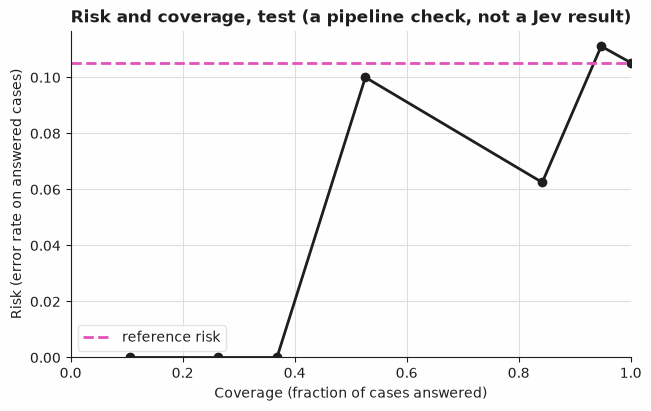

In [11]:
test_accepted = [r.outcome == helpers.ACCEPTED for r in test_results]
test_correct = [p == g for p, g in zip(test_task_pred, test_task_gold, strict=True)]
selective = evaluate_outcomes(test_accepted, test_correct)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

test_gate_confidence = [helpers.gate_confidence(*test_decisions[e.id]) for e in test_examples]
curve = selective_curve(test_correct, test_gate_confidence)
print(f"risk-coverage sweep over the confidence gate, test{check}:")
for curve_threshold, cov, risk in zip(curve.thresholds, curve.coverage, curve.risk, strict=True):
    print(f"  gate {curve_threshold:.2f}: coverage {cov:.4f}, risk {risk:.4f}{check}")
plot_risk_coverage(
    curve,
    reference_risk=1 - accuracy(test_task_gold, test_task_pred),
    title=f"Risk and coverage, test{check}",
)

At this gate, `t19-wrong`'s confident mistake clears the bar, which is why `risk` above is not `0`. A gate chosen to have perfect task-level agreement on `validation` is a guarantee about `validation`, not about `test` or about any ticket this recipe has not seen. Here the gate still earns its place on `test`: ungated task-level agreement is 0.8947 (17 of 19), while accuracy among the 16 tickets the gate accepts is 0.9375 (15 of 16) -- higher, because the gate catches `t09`'s unconfident mistake and withholds it rather than composing it silently wrong. But the gate does not catch everything: `t19-wrong`'s mistake is exactly as confident as a correct answer, so it clears the same bar and keeps `risk` above `0`. The other two tickets sent to review, `t17-one-confident` and `t18-one-confident`, are both tickets whose weaker question could not clear the gate and both would have been composed correctly anyway -- real coverage paid for one caught mistake, not two. The lesson is not that a frozen gate is safe; it is that a gate tuned on `validation` can raise accuracy among what it accepts while still letting a confident mistake through, and a reader should check both numbers rather than only the accepted/review split.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the composition and the confidence gate behave as designed on 38 scored tickets (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, one of them wrong on purpose and confident enough to clear the frozen gate, so every number above describes this fixture set and not a model.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test tickets")
demo_count = len(examples) - len(scored)
print(
    f"Requests to decisions: {len(scored)} scored tickets + {demo_count} demo tickets = "
    f"{len(answered)} requests, 2 questions each = {2 * len(answered)} judgments.{check}"
)

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.
Requests to decisions: 38 scored tickets + 2 demo tickets = 40 requests, 2 questions each = 80 judgments. (a pipeline check, not a Jev result)


## Next steps

- Add a ticket to `ROWS` in `build_fixtures.py` whose impact and urgency pull in different directions and see what priority the matrix gives it, then run `python build_fixtures.py`.
- Edit one cell of `PRIORITY_MATRIX` in `helpers.py` and re-run `pytest recipes/24-incident-priority-composition`: the one test for that cell fails, and every other cell's test still passes.
- Change the confidence gate's `target_accuracy` in the evaluation section from `1.0` to `0.90` and see how coverage and the review count trade off: the gate drops from `0.6700` to `0.0600`, `validation` coverage rises from 16 of 19 tickets to all 19, and `validation` accuracy among those accepted falls from `1.0000` to `0.9474`. (Targets between `1.0` and about `0.95` leave the gate exactly where it is, because no `validation` ticket's gate confidence falls strictly between those two accuracy levels; `0.90` is comfortably past that gap.)
- Neighbouring recipes: [`03-response-clarity-scoring`](../03-response-clarity-scoring/) (a single `Score` question and its confidence threshold) and [`04-support-ticket-routing`](../04-support-ticket-routing/) (a `Choice` question composed with a Python rule), to compare how this recipe's two-question composition builds on a single-question `Score` rule.